In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
from scipy import stats
from scipy.stats import median_abs_deviation

In [26]:
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'figure.titlesize': 16,
    'axes.titlesize': 16,
    'axes.labelsize': 12,

    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',

    'legend.frameon': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.axisbelow': True
})

In [27]:
def format_plot(ax, title, xlabel, ylabel, horizontal=False):

    ax.set_title(title, pad=20)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if horizontal:
        ax.grid(axis='x', linestyle='--', alpha=0.5)
        ax.grid(axis='y', visible=False)
    else:
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.grid(axis='x', visible=False)

In [28]:
def get_clean_mask(data, threshold=3.5):
    """
    Apply Iglewicz and Hoaglin's robust outlier detection.
    Returns: Boolean mask (True = Valid, False = Outlier)
    """
    median = np.median(data)
    mad = median_abs_deviation(data, scale='normal')
    modified_z_score = 0.6745 * (data - median) / mad
    return modified_z_score.abs() < threshold

def get_limits(data, sigma=3.5, min_floor=0.5, reference_col=None, cv_floor=0.015):
    """
    Calculates a ROBUST SYMMETRIC limit.
    Hybrid Mode: Supports both FIXED floors (e.g., 0.5 kg) and DYNAMIC floors (e.g., 1.5% of TBW).

    Args:
    - data (Series): The error/difference column.
    - sigma (float): Outlier threshold (default 3.5).
    - min_floor (float): The default HARD floor (used if reference_col is None).
    - reference_col (Series, Optional): The magnitude column (e.g., TBW).
      If provided, the floor becomes dynamic (Mean of Ref * cv_floor).
    - cv_floor (float): The percentage noise floor (default 1.5% = 0.015).
    """
    # 1. Clean Data (Drop NaNs)
    clean_data = data.dropna()

    # 2. Calculate Statistical Limit (MAD)
    # This captures the natural spread of your specific dataset
    mad = stats.median_abs_deviation(clean_data, scale=1.4826)
    stat_limit = sigma * mad

    # 3. Determine the Floor Strategy
    if reference_col is not None:
        # [DYNAMIC MODE] Floor = % of the Reference Magnitude
        # Align reference to clean_data indices to avoid size mismatch
        ref_clean = reference_col.loc[clean_data.index]
        floor_val = ref_clean.abs().mean() * cv_floor
    else:
        # [STATIC MODE] Floor = Fixed Number (Backwards Compatible)
        floor_val = min_floor

    # 4. Final Limit: The Greater of the Two
    # Prevents collapse on perfect data, but respects physics on noisy data.
    return max(stat_limit, floor_val)

In [29]:
# --- 1. THE LOW-LEVEL WORKER (Draws one column) ---
def _plot_single_track(data, title, ax_box, ax_hist, unit="kg", target_val=0.0):
    """
    Internal helper: Draws the boxplot and histogram on specific axes.
    """
    # Boxplot (Top)
    sns.boxplot(x=data, ax=ax_box, color='tab:red', width=0.5,
                flierprops={"marker": "x", "markeredgecolor": "firebrick", "markersize": 8})
    ax_box.set_title(f"{title}\nOutlier Detection", fontweight='bold', fontsize=10)
    ax_box.axvline(target_val, color='black', linestyle='--', alpha=0.5)
    ax_box.set_xlabel("")
    ax_box.tick_params(axis='x', labelbottom=False)

    # Histogram (Bottom)
    if not data.isnull().all():
        sns.histplot(x=data, ax=ax_hist, color='#E6B0AA', bins=30, kde=True,
                     line_kws={'linewidth': 2, 'color': 'firebrick'})

        mean_val = data.mean()
        ax_hist.axvline(mean_val, color='black', linestyle='--', label=f'Mean: {mean_val:.2f} {unit}')
        ax_hist.axvline(target_val, color='green', linestyle=':', alpha=0.5, label=f'Target: {target_val} {unit}')
        ax_hist.legend(loc='upper right', fontsize=9)

    ax_hist.set_title("Distribution Shape", fontweight='bold', fontsize=10)
    ax_hist.set_xlabel(f"Residual Error ({unit})")

# --- 2. THE HIGH-LEVEL MANAGER (Takes only tracks) ---
def plot_all_tracks(df, tracks, figure_title="Distribution Analysis"):
    """
    Master function. Handles layout creation and iteration automatically.

    Args:
        df (pd.DataFrame): The source dataframe.
        tracks (list of tuples): List of (Title, Column_Name, Unit).
                                 Example: [('Title A', 'col_a', 'kg'), ...]
        figure_title (str): Global title for the figure.
    """
    n_tracks = len(tracks)

    # Dynamic Layout: Create 2 rows (Box + Hist) and N columns (Tracks)
    fig, axes = plt.subplots(2, n_tracks, figsize=(6 * n_tracks, 10),
                             constrained_layout=True, sharex='col')

    # Handle the edge case where n_tracks=1 (axes is 1D array, needs 2D logic)
    if n_tracks == 1:
        axes = np.array([[axes[0]], [axes[1]]])

    # Iteration Logic
    for i, (title, col_name, unit) in enumerate(tracks):
        # Safety Check: Does column exist?
        if col_name not in df.columns:
            print(f"⚠️ WARNING: Column '{col_name}' not found. Skipping.")
            continue

        _plot_single_track(
            data=df[col_name],
            title=title,
            ax_box=axes[0, i],   # Row 0 = Boxplot
            ax_hist=axes[1, i],  # Row 1 = Histogram
            unit=unit
        )

    plt.suptitle(figure_title, y=1.05, fontsize=18, fontweight='bold')
    plt.show()

In [30]:
def plot_logic_map(df, track_config):
    """
    Plots the 5-State Logic Map using the EXACT logic and styling provided.

    Args:
        df (pd.DataFrame): The source dataframe containing data and masks.
        track_config (dict): A dictionary mapping the generic logic to your specific column names.
    """

    # --- UNPACK CONFIGURATION ---
    # We map generic names to your specific variables to allow swapping tracks
    x_col = track_config['x_col']
    y_col = track_config['y_col']

    lim_x = track_config['lim_x']
    lim_y = track_config['lim_y']
    lim_sum = track_config['lim_sum']

    # Boolean Masks (Series of True/False)
    mask_fit = track_config['mask_fit']
    mask_fail_x = track_config['mask_fail_x']
    mask_fail_y = track_config['mask_fail_y']
    mask_rescue = track_config['mask_rescue']
    mask_fail_all = track_config['mask_fail_all']

    # --- START PLOTTING (Your Original Code) ---
    fig, ax = plt.subplots(figsize=(12, 12), constrained_layout=True)

    # 1. DYNAMIC ZOOM (Context-Aware)
    max_val = max(
        df[x_col].abs().max(),
        df[y_col].abs().max(),
        lim_x,
        lim_y,
        lim_sum,
        40
    ) * 1.15

    # === 2. DRAW SAFETY ZONES (Background) ===

    # A. Diagonal "Rescue" Zone (The Sum Limit)
    diag_x = np.linspace(-max_val * 2, max_val * 2, 100)
    ax.fill_between(diag_x, diag_x - lim_sum, diag_x + lim_sum,
                    color='#E8F5E9', alpha=0.6, zorder=0, label='Sum Logic Zone')

    # B. The "Perfect Box" (Lean & Ratio Limits)
    ax.fill_between([-lim_x, lim_x],
                    -lim_y, lim_y,
                    color='#FFF3E0', alpha=0.5, zorder=1, label='Strict Limits Box')

    # Draw Boundary Lines
    ax.axvline(-lim_x, color='#FF9800', linestyle='--', alpha=0.4)
    ax.axvline(lim_x, color='#FF9800', linestyle='--', alpha=0.4)
    ax.axhline(-lim_y, color='#FF9800', linestyle='--', alpha=0.4)
    ax.axhline(lim_y, color='#FF9800', linestyle='--', alpha=0.4)

    # === 3. PLOT THE 5 LOGIC STATES ===

    def annotate_points(data_subset, color, y_offset=0):
        """Helper to label points with their ID"""
        if len(data_subset) > 0:
            for i, row in data_subset.iterrows():
                ax.text(row[x_col], row[y_col] + y_offset,
                        f"{row.name}",
                        fontsize=8, fontweight='bold', color=color,
                        ha='center', va='bottom', zorder=20)

    # 1. FIT BOTH (Perfect)
    sns.scatterplot(data=df[mask_fit],
                    x=x_col, y=y_col,
                    color='gray', alpha=0.3, s=30, label='Fit (Strict)', ax=ax, zorder=2)

    # 2. FAIL LEAN ONLY (Ratio is Good)
    data_fail_lean = df[mask_fail_x]
    sns.scatterplot(data=data_fail_lean, x=x_col, y=y_col,
                    color='#1E88E5', s=80, marker='v', label='Fail X Only (Lean)', ax=ax, zorder=4)
    annotate_points(data_fail_lean, '#0D47A1', y_offset=max_val*0.02)

    # 3. FAIL RATIO ONLY (Lean is Good)
    data_fail_ratio = df[mask_fail_y]
    sns.scatterplot(data=data_fail_ratio, x=x_col, y=y_col,
                    color='#8E24AA', s=80, marker='<', label='Fail Y Only (Ratio)', ax=ax, zorder=4)
    annotate_points(data_fail_ratio, '#4A148C', y_offset=max_val*0.02)

    # 4. RESCUE (SUM LOGIC)
    data_rescue = df[mask_rescue]
    sns.scatterplot(data=data_rescue, x=x_col, y=y_col,
                    color='#43A047', s=100, marker='P', edgecolor='black', label='Rescue (Sum Logic)', ax=ax, zorder=5)
    annotate_points(data_rescue, '#1B5E20', y_offset=max_val*0.02)

    # 5. FAIL ALL (CRITICAL)
    data_fail_all = df[mask_fail_all]
    sns.scatterplot(data=data_fail_all, x=x_col, y=y_col,
                    color='#D32F2F', s=150, marker='X', edgecolor='white', linewidth=1.5, label='FAIL ALL', ax=ax, zorder=10)
    annotate_points(data_fail_all, '#B71C1C', y_offset=max_val*0.03)


    # === 4. FINAL POLISH ===
    ax.set_aspect('equal')
    ax.set_xlim(-max_val, max_val)
    ax.set_ylim(-max_val, max_val)

    # Dynamic Title
    title_text = track_config.get('title', "5-State Logic Classification Map")
    ax.set_title(title_text, fontweight='bold', fontsize=14)
    ax.set_xlabel(f"Lean Deviation (X) [Limit: ±{lim_x}]")
    ax.set_ylabel(f"Ratio Deviation (Y) [Limit: ±{lim_y}]")

    # Center Crosshairs
    ax.axhline(0, color='black', linewidth=1, alpha=0.8, zorder=3)
    ax.axvline(0, color='black', linewidth=1, alpha=0.8, zorder=3)

    ax.legend(loc='upper left', framealpha=0.95, fontsize='small')
    ax.grid(True, linestyle=':', alpha=0.4)

    plt.show()

In [31]:
def _Bland_Altman_comparison(dataframe, col_mean_raw, col_diff_raw, col_mean_fixed, col_diff_fixed, col_fix_bool):
    """
    Final Output:
    - Global Y-Limits (Honest Comparison).
    - Shaded Confidence Zones (Visual Clarity).
    - Logic: Green = 'Repaired' (Algorithm touched it).
    - Labels: 'Repaired Data', 'Difference (Method - Ref)', 'Mean (Repaired + Ref) / 2'.
    - Annotations: Top 5 Outliers labeled with IDs.
    """

    # Create local copy to avoid modifying original df
    df = dataframe.copy()

    # --- 1. GLOBAL LIMITS ---
    # Calculate limits from BOTH datasets so the Y-axis is identical
    y_all = pd.concat([df[col_diff_raw], df[col_diff_fixed]])
    y_max = y_all.max()
    y_min = y_all.min()
    y_range = y_max - y_min
    # Add 12% padding for labels
    y_lims = (y_min - y_range * 0.12, y_max + y_range * 0.12)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

    # Colors
    c_valid  = '#95a5a6' # Concrete Grey
    c_bad    = '#e74c3c' # Alizarin Red
    c_good   = '#27ae60' # Nephritis Green

    # Helper for Stats Box
    def add_stats_box(ax, data, loc='lower right'):
        mean = data.mean()
        sd = data.std()
        loa_up = mean + 1.96 * sd
        loa_low = mean - 1.96 * sd

        stats_text = (f"Bias: {mean:.2f}\n"
                      f"SD: {sd:.2f}\n"
                      f"LOA: [{loa_low:.2f}, {loa_up:.2f}]")
        at = AnchoredText(stats_text, prop=dict(size=10, fontfamily='monospace'),
                          frameon=True, loc=loc)
        at.patch.set_boxstyle("round,pad=0.2,rounding_size=0.2")
        at.patch.set_edgecolor('#dcdcdc')
        at.patch.set_alpha(0.95)
        ax.add_artist(at)
        return mean, loa_up, loa_low

    # ==========================================
    # PANEL A: RAW DATA
    # ==========================================
    mean_a, loa_up_a, loa_low_a = add_stats_box(ax1, df[col_diff_raw])

    # Identify Raw Outliers
    mask_outlier = (df[col_diff_raw] > loa_up_a) | (df[col_diff_raw] < loa_low_a)

    # Shaded Region (Safe Zone)
    ax1.axhspan(loa_low_a, loa_up_a, color=c_good, alpha=0.05, zorder=0)

    # Plot Points
    ax1.scatter(df.loc[~mask_outlier, col_mean_raw], df.loc[~mask_outlier, col_diff_raw],
                c=c_valid, alpha=0.5, s=40, label='Valid', zorder=1)
    # Slight transparency on red dots in Panel A to match Panel B's aesthetic
    ax1.scatter(df.loc[mask_outlier, col_mean_raw], df.loc[mask_outlier, col_diff_raw],
                c=c_bad, alpha=0.9, s=60, label='Outlier', zorder=2, edgecolors='white', linewidth=0.5)

    # Reference Lines
    ax1.axhline(mean_a, color='black', lw=1.5, zorder=3)
    ax1.axhline(loa_up_a, color='black', ls=':', lw=1.2, zorder=3)
    ax1.axhline(loa_low_a, color='black', ls=':', lw=1.2, zorder=3)

    # Labels Panel A
    ax1.set_title("A. Raw Data", pad=15)
    ax1.set_xlabel("Mean (Raw + Ref) / 2")
    ax1.set_ylabel("Difference (Method - Ref)")
    ax1.set_ylim(y_lims) # Force Global Scale

    # ==========================================
    # PANEL B: REPAIRED DATA
    # ==========================================
    mean_b, loa_up_b, loa_low_b = add_stats_box(ax2, df[col_diff_fixed])

    # --- LOGIC ---
    cond_outlier = (df[col_diff_fixed] > loa_up_b) | (df[col_diff_fixed] < loa_low_b)

    # Priority: 1. Algorithm Touched -> Green, 2. Else -> Red/Gray
    conditions = [
        df[col_fix_bool].astype(bool),
        cond_outlier,
    ]
    choices = ['Repaired', 'Unresolved']

    df['Status'] = np.select(conditions, choices, default='Valid')

    # --- PLOTTING ---

    # Layer 1: Valid Background (Pushed back)
    ax2.scatter(df.loc[df['Status']=='Valid', col_mean_fixed],
                df.loc[df['Status']=='Valid', col_diff_fixed],
                c=c_valid, alpha=0.2, s=40, zorder=1)

    # Layer 2: Action Data
    palette = {'Repaired': c_good, 'Unresolved': c_bad}
    markers = {'Repaired': 'X',    'Unresolved': 'P'}

    df_action = df[df['Status'].isin(palette.keys())].copy()

    if not df_action.empty:
        sns.scatterplot(data=df_action, x=col_mean_fixed, y=col_diff_fixed,
                        hue='Status', style='Status',
                        palette=palette, markers=markers,
                        s=100, edgecolor='white', linewidth=0.5,
                        ax=ax2, zorder=3)

    # Shaded Region
    ax2.axhspan(loa_low_b, loa_up_b, color=c_good, alpha=0.1, zorder=0)

    # Reference Lines
    ax2.axhline(mean_b, color='black', lw=1.5, zorder=3)
    ax2.axhline(loa_up_b, color=c_good, ls='--', lw=1.5, zorder=3)
    ax2.axhline(loa_low_b, color=c_good, ls='--', lw=1.5, zorder=3)

    # --- ANNOTATIONS (ENABLED) ---
    # Label top 5 worst Unresolved/Repaired points if they are outliers
    # We focus on 'Unresolved' first as they are critical errors
    df_bad = df[df['Status'] == 'Unresolved']

    if not df_bad.empty:
        top_fails = df_bad.reindex(
            df_bad[col_diff_fixed].abs().sort_values(ascending=False).index
        ).head(5)

        for idx, row in top_fails.iterrows():
            ax2.annotate(f"{idx}", (row[col_mean_fixed], row[col_diff_fixed]),
                         xytext=(0, 7), textcoords='offset points', ha='center',
                         fontsize=9, fontweight='bold', color=c_bad,
                         bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.7, ec="none"))

    # Labels Panel B
    ax2.set_title("B. Repaired Data", pad=15)
    ax2.set_xlabel("Mean (Repaired + Ref) / 2") # Matching Title

    # Clean Legend
    if ax2.get_legend():
        ax2.legend(title='', loc='upper right', framealpha=0.95)

    plt.tight_layout()
    plt.show()

In [32]:
filePath = '../Dataset/UCI_Gallstone_Dataset.csv'
df = pd.read_csv(filePath)

In [33]:
df_bioimpedance = df[[
    'Weight',
    'Total Body Water (TBW)',         # Measured in kg
    'Extracellular Water (ECW)',      # Measured in kg
    'Intracellular Water (ICW)',      # Measured in kg
    'Extracellular Fluid/Total Body Water (ECF/TBW)', # Derived Fluid Ratio
    'Total Body Fat Ratio (TBFR) (%)',# Percentage of total mass
    'Lean Mass (LM) (%)',             # Percentage of fat-free mass
    'Body Protein Content (Protein) (%)', # Protein composition percentage
    'Visceral Fat Rating (VFR)',      # Corresponds to "Visceral Adiposity Index" in text [cite: 61]
    'Bone Mass (BM)',                 # Measured in kg
    'Muscle Mass (MM)',               # Measured in kg
    'Obesity (%)',                    # Degree of obesity percentage
    'Total Fat Content (TFC)',        # Measured in kg
    'Visceral Fat Area (VFA)',        # Measured in kg
    'Visceral Muscle Area (VMA) (Kg)' # Measured in kg
]].copy()
df_bioimpedance

,Weight,Total Body Water (TBW),Extracellular Water (ECW),Intracellular Water (ICW),Extracellular Fluid/Total Body Water (ECF/TBW),Total Body Fat Ratio (TBFR) (%),Lean Mass (LM) (%),Body Protein Content (Protein) (%),Visceral Fat Rating (VFR),Bone Mass (BM),Muscle Mass (MM),Obesity (%),Total Fat Content (TFC),Visceral Fat Area (VFA),Visceral Muscle Area (VMA) (Kg)
0,92.8,52.9,21.2,31.7,40.00,19.20,80.84,18.88,9,3.7,71.4,23.40,17.8,10.60,39.7
1,94.5,43.1,19.5,23.6,45.00,32.80,67.20,16.68,15,3.2,60.3,38.80,31.0,18.40,32.7
2,91.1,47.2,20.1,27.1,43.00,27.30,72.67,16.35,15,3.3,62.9,41.70,24.9,16.20,34.0
3,67.7,41.4,17.0,24.4,41.00,15.80,84.19,16.90,6,2.9,54.1,9.00,10.7,6.50,29.2
4,89.6,51.4,20.0,31.4,39.00,20.00,80.02,16.81,8,3.5,68.2,28.60,17.9,10.40,37.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,88.8,47.6,20.0,28.0,42.01,24.66,75.23,16.13,11,3.3,63.5,14.39,21.9,13.58,34.2
315,53.4,29.3,12.3,17.0,42.00,23.60,76.40,15.96,2,2.1,38.7,1.50,12.6,5.10,22.2
316,96.6,49.2,21.0,28.2,43.00,28.80,71.22,15.87,16,3.4,65.4,48.40,27.8,17.10,35.6
317,88.4,50.2,19.9,30.3,40.00,21.10,78.85,16.30,8,3.4,66.3,28.30,18.7,11.00,36.1


In [34]:
# Track A: Physics (Summation) | TBW - (ECW + ICW)
col_TBW_calc_sum = 'TBW_calc_sum'
df_bioimpedance[col_TBW_calc_sum] = df_bioimpedance['Extracellular Water (ECW)'] + df_bioimpedance['Intracellular Water (ICW)']

col_TBW_disc_sum = 'TBW_disc_sum'
df_bioimpedance[col_TBW_disc_sum] = df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance[col_TBW_calc_sum]

# Track B: Logic (Ratio) | TBW - ECW / (Ratio/100)
col_TBW_calc_ratio = 'TBW_calc_ratio'
df_bioimpedance[col_TBW_calc_ratio] = df_bioimpedance['Extracellular Water (ECW)'] / (df_bioimpedance['Extracellular Fluid/Total Body Water (ECF/TBW)'] / 100)

col_TBW_disc_ratio = 'TBW_disc_ratio'
df_bioimpedance[col_TBW_disc_ratio] = df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance[col_TBW_calc_ratio]

col_TBW_calc_sumOfRatio = 'TBW_calc_sumOfRatio'
df_bioimpedance[col_TBW_calc_sumOfRatio] = df_bioimpedance['Extracellular Fluid/Total Body Water (ECF/TBW)'] + df_bioimpedance['Intracellular Water (ICW)']/df_bioimpedance['Total Body Water (TBW)']*100

col_TBW_disc_sumOfRatio = 'TBW_disc_sumOfRatio'
df_bioimpedance[col_TBW_disc_sumOfRatio] = 100 - df_bioimpedance[col_TBW_calc_sumOfRatio]

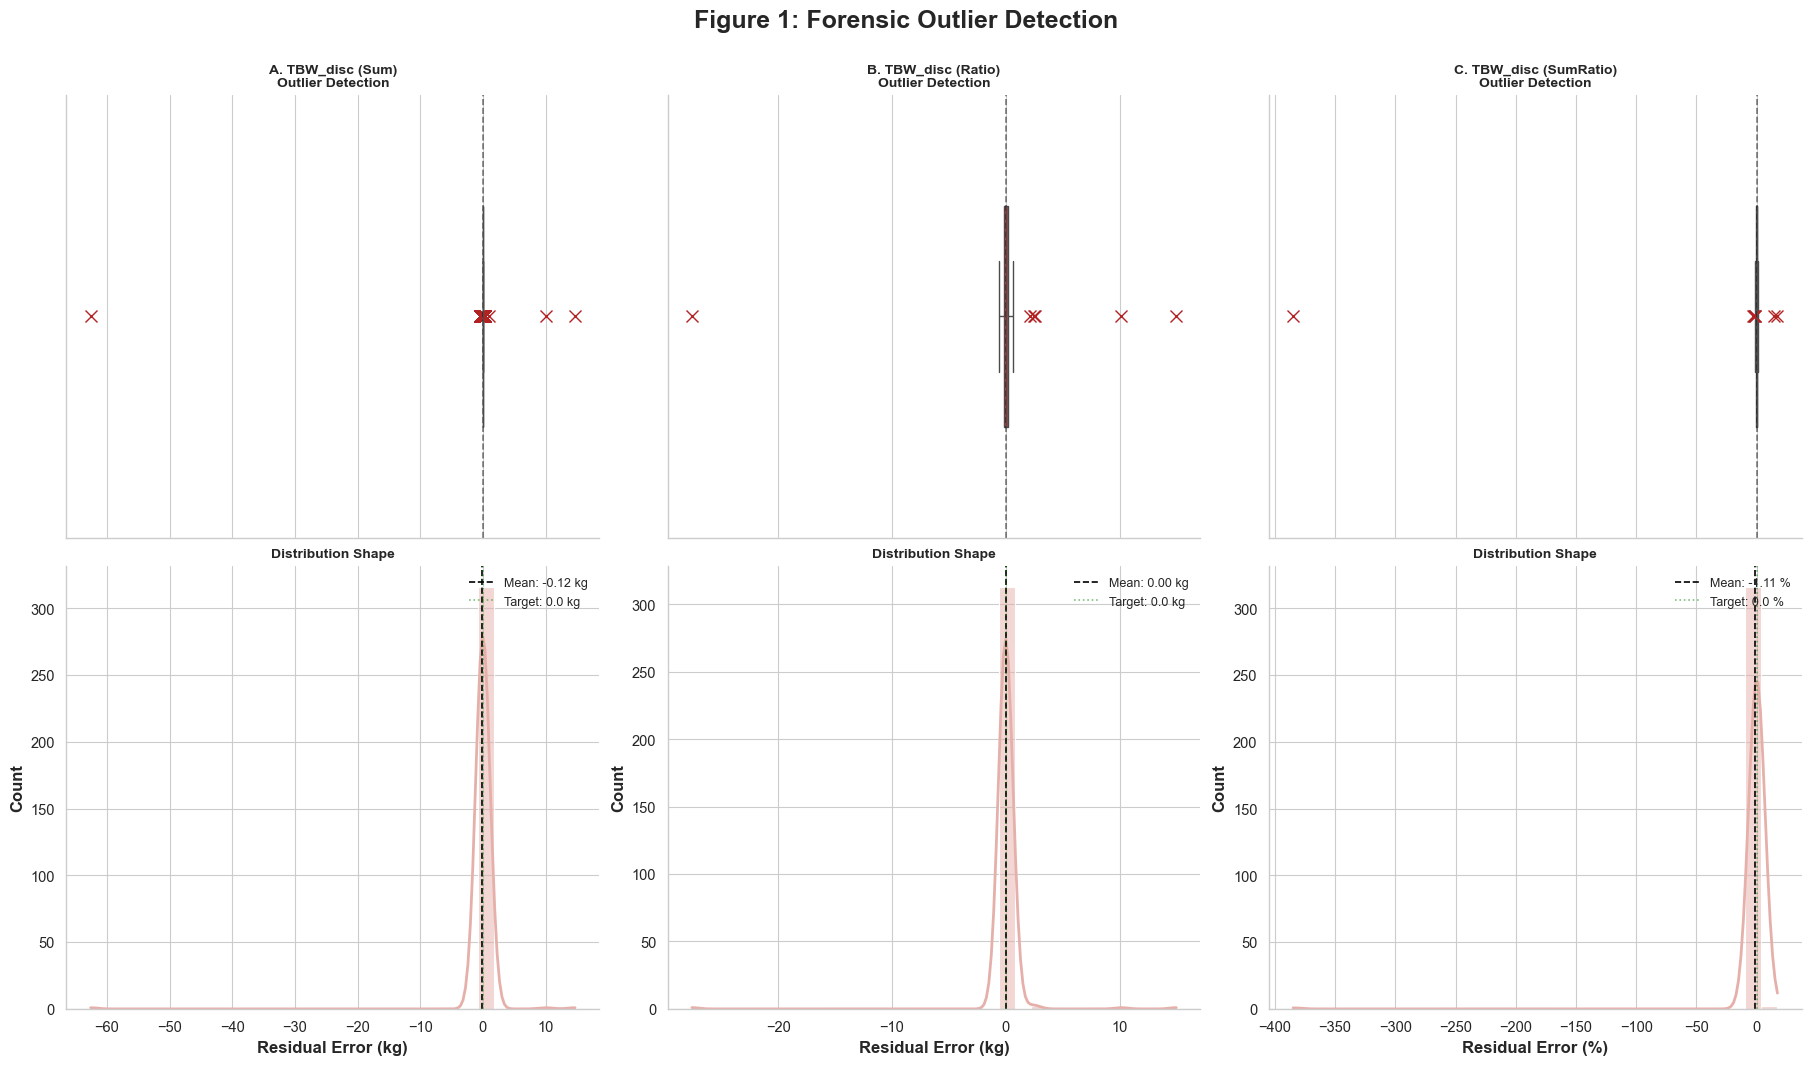

In [35]:
# --- CONFIGURATION ---
my_tracks = [
    ('A. TBW_disc (Sum)',    col_TBW_disc_sum,       'kg'),
    ('B. TBW_disc (Ratio)',   col_TBW_disc_ratio,      'kg'),
    ('C. TBW_disc (SumRatio)',col_TBW_disc_sumOfRatio, '%')
]

plot_all_tracks(df_bioimpedance, my_tracks, figure_title="Figure 1: Forensic Outlier Detection")

In [36]:
TBW_disc_sum_lim_val = get_limits(df_bioimpedance[col_TBW_disc_sum],reference_col=df_bioimpedance['Total Body Water (TBW)'])
TBW_disc_ratio_lim_val = get_limits(df_bioimpedance[col_TBW_disc_ratio],reference_col=df_bioimpedance['Total Body Water (TBW)'])
TBW_disc_sumOfRatio_lim_val = 2.5


# 2. GENERATE MASKS (Using the new symmetric limits)
TBW_disc_fit_sum_lim = (df_bioimpedance[col_TBW_disc_sum].abs() < TBW_disc_sum_lim_val)
TBW_disc_fit_ratio_lim = (df_bioimpedance[col_TBW_disc_ratio].abs() < TBW_disc_ratio_lim_val)
TBW_disc_fit_sumOfRatio_lim = (df_bioimpedance[col_TBW_disc_sumOfRatio].abs() < TBW_disc_sumOfRatio_lim_val)

TBW_disc_fit_both_lim       =  TBW_disc_fit_sum_lim &  TBW_disc_fit_ratio_lim
TBW_disc_fail_ratio_lim     =  TBW_disc_fit_sum_lim & ~TBW_disc_fit_ratio_lim
TBW_disc_fail_sum_lim       = ~TBW_disc_fit_sum_lim &  TBW_disc_fit_ratio_lim
TBW_disc_fit_sumOfRatio_lim = ~TBW_disc_fit_sum_lim & ~TBW_disc_fit_ratio_lim &  TBW_disc_fit_sumOfRatio_lim
TBW_disc_fail_all_lim       = ~TBW_disc_fit_sum_lim & ~TBW_disc_fit_ratio_lim & ~TBW_disc_fit_sumOfRatio_lim

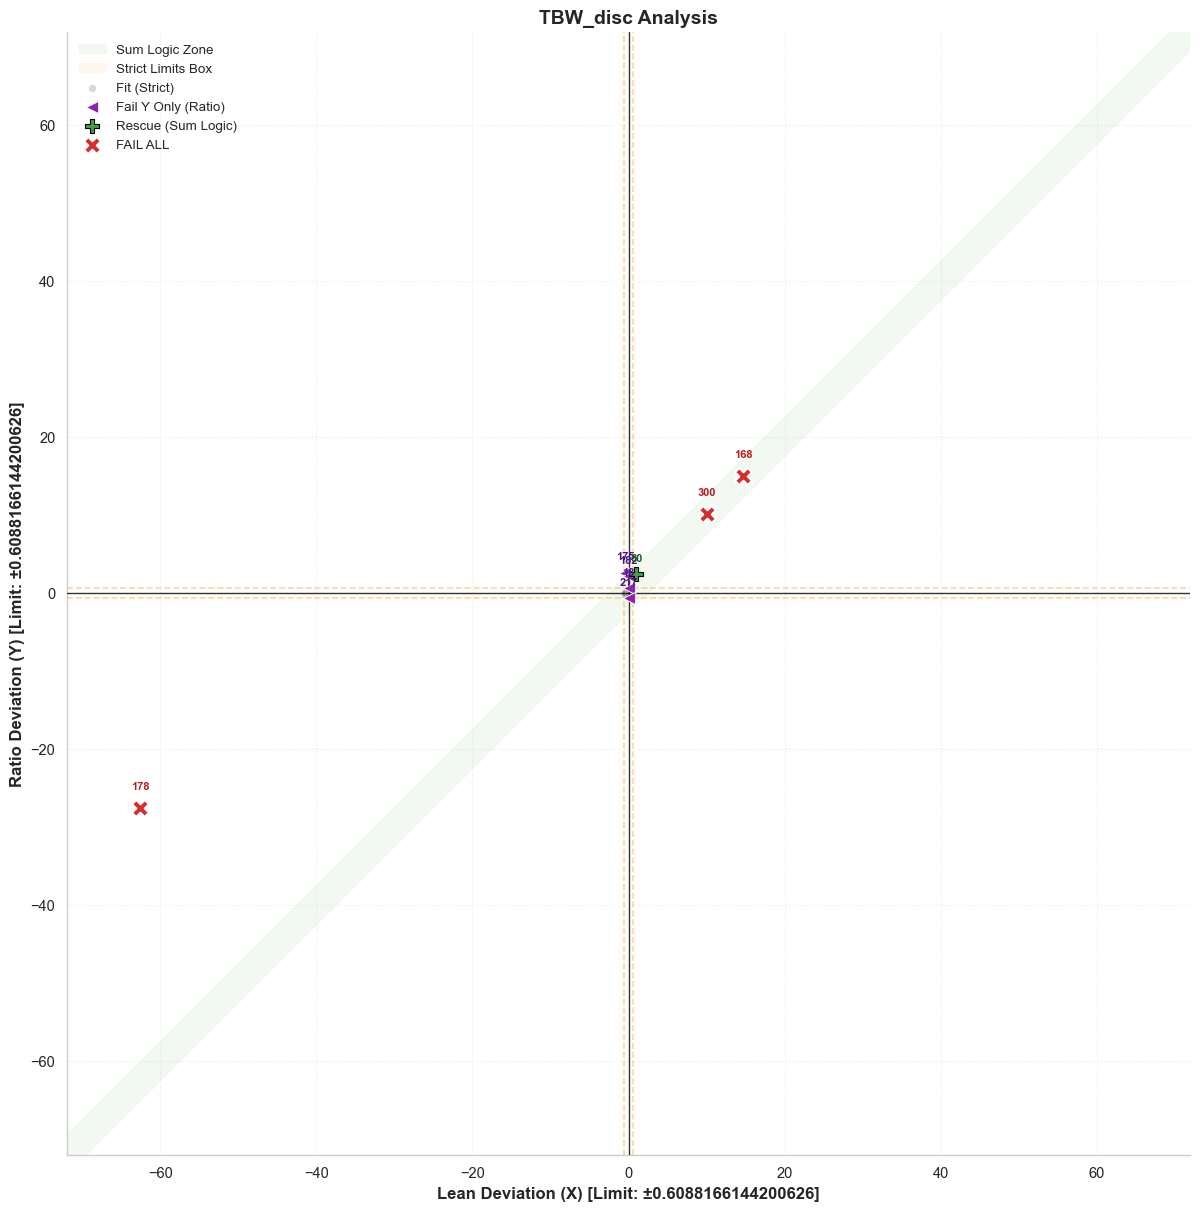

In [37]:
# --- 1. DEFINE YOUR TRACK CONFIGURATION ---
current_track = {
    'title': "TBW_disc Analysis",

    # Columns
    'x_col': col_TBW_disc_sum,
    'y_col': col_TBW_disc_ratio,

    # Limits (Values)
    'lim_x': TBW_disc_sum_lim_val,
    'lim_y': TBW_disc_ratio_lim_val,
    'lim_sum': TBW_disc_sumOfRatio_lim_val,

    # Masks (Boolean Series)
    'mask_fit': TBW_disc_fit_both_lim,
    'mask_fail_x': TBW_disc_fail_sum_lim,
    'mask_fail_y': TBW_disc_fail_ratio_lim,
    'mask_rescue': TBW_disc_fit_sumOfRatio_lim,
    'mask_fail_all': TBW_disc_fail_all_lim
}

# --- 2. EXECUTE ---
plot_logic_map(df_bioimpedance, current_track)

In [38]:
# Fixing TBW column
col_ICW_fixed = 'ICW_fixed'
df_bioimpedance[col_ICW_fixed] = df_bioimpedance['Intracellular Water (ICW)']
col_ICW_fix_status = 'ICW_fixed_status'
df_bioimpedance[col_ICW_fix_status] = False

col_ECF_TBW_fixed = 'ECF/TBW_fixed'
df_bioimpedance[col_ECF_TBW_fixed] = df_bioimpedance['Extracellular Fluid/Total Body Water (ECF/TBW)']
col_ECF_TBW_fix_status = 'ECF/TBW_fixed_status'
df_bioimpedance[col_ECF_TBW_fix_status] = False

col_TBW_fixed = 'TBW_fixed'
df_bioimpedance[col_TBW_fixed] = df_bioimpedance['Total Body Water (TBW)']
col_TBW_fix_status = 'TBW_fixed_status'
df_bioimpedance[col_TBW_fix_status] = False

# CASE 1: Ratio Failed, sum correct -> Assume ICW, ECW and TBW are correct, ECF/TBW is wrong
col_ECF_TBW_calc_ratio = 'ECF/TBW_calc_ratio'
df_bioimpedance[col_ECF_TBW_calc_ratio] = df_bioimpedance['Extracellular Water (ECW)']/df_bioimpedance['Total Body Water (TBW)']
df_bioimpedance.loc[TBW_disc_fail_ratio_lim, col_ECF_TBW_fixed] = df_bioimpedance.loc[TBW_disc_fail_ratio_lim, col_ECF_TBW_calc_ratio]
df_bioimpedance.loc[TBW_disc_fail_ratio_lim, col_ECF_TBW_fix_status] = True

# CASE 2: Sum Failed, ratio correct -> Assume ECF/TBW, ECW and TBW are correct, ICW is wrong
col_ICW_calc_sum = 'ICW_calc_sum'
df_bioimpedance[col_ICW_calc_sum] = df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance['Extracellular Water (ECW)']
df_bioimpedance.loc[TBW_disc_fail_sum_lim, col_ICW_fixed] = df_bioimpedance.loc[TBW_disc_fail_sum_lim, col_ICW_calc_sum]
df_bioimpedance.loc[TBW_disc_fail_sum_lim, col_ICW_fix_status] = True

# === CASE 3: Both Failed but sum of ratio near 100% -> Assume ECF/TBW, ECW and ICW are correct, TBW is wrong
df_bioimpedance.loc[TBW_disc_fit_sumOfRatio_lim, col_TBW_fixed] = df_bioimpedance.loc[TBW_disc_fit_sumOfRatio_lim, col_TBW_calc_ratio]
df_bioimpedance.loc[TBW_disc_fit_sumOfRatio_lim, col_TBW_fix_status] = True

In [39]:
# Track C: 4-Component Model | TBW - (Weight - Fat - Bone - Protein - 0.013*Weight)
epsilon_4C = df_bioimpedance['Weight']*0.013

col_TFC_calc_ratio = 'TFC_calc_ratio'
df_bioimpedance[col_TFC_calc_ratio] = (df_bioimpedance['Weight'] * (df_bioimpedance['Total Body Fat Ratio (TBFR) (%)'] / 100))

col_TPC_calc_ratio = 'TPC_calc_ratio'
df_bioimpedance[col_TPC_calc_ratio] = (df_bioimpedance['Weight'] * (df_bioimpedance['Body Protein Content (Protein) (%)'] / 100))

col_TBW_calc_4C = 'TBW_calc_4C'
df_bioimpedance[col_TBW_calc_4C] = df_bioimpedance['Weight'] - df_bioimpedance[col_TFC_calc_ratio] - df_bioimpedance['Bone Mass (BM)'] - df_bioimpedance[
    col_TPC_calc_ratio] - epsilon_4C

col_TBW_disc_4C = 'TBW_disc_4C'
df_bioimpedance[col_TBW_disc_4C] = df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance[col_TBW_calc_4C]

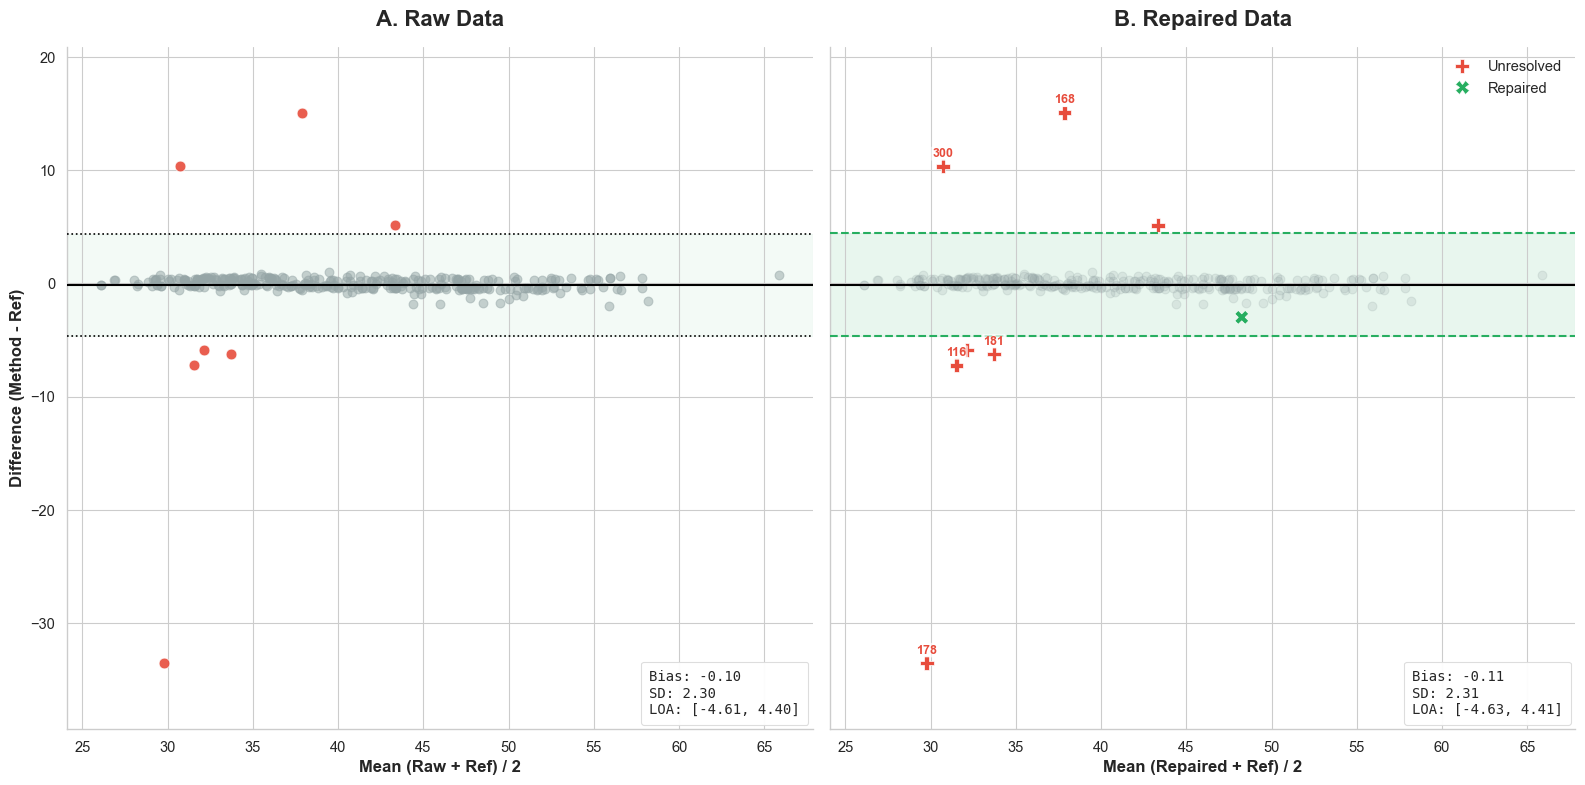

In [40]:
col_TBW_mean_raw = 'TBW_mean_raw'
df_bioimpedance[col_TBW_mean_raw] = (df_bioimpedance['Total Body Water (TBW)'] + df_bioimpedance[col_TBW_calc_4C]) / 2
col_TBW_diff_raw = 'TBW_diff_raw'
df_bioimpedance[col_TBW_diff_raw] = df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance[col_TBW_calc_4C]
col_TBW_mean_fixed = 'TBW_mean_fixed'
df_bioimpedance[col_TBW_mean_fixed] = (df_bioimpedance[col_TBW_fixed] + df_bioimpedance[col_TBW_calc_4C]) / 2
col_TBW_diff_fixed = 'TBW_diff_fixed'
df_bioimpedance[col_TBW_diff_fixed] = df_bioimpedance[col_TBW_fixed] - df_bioimpedance[col_TBW_calc_4C]

_Bland_Altman_comparison(df_bioimpedance,col_TBW_mean_raw,col_TBW_diff_raw,col_TBW_mean_fixed,col_TBW_diff_fixed,col_TBW_fix_status)

In [41]:
col_TFC_calc_lean = 'TFC_calc_lean'
df_bioimpedance[col_TFC_calc_lean] = df_bioimpedance['Weight'] - (df_bioimpedance['Weight'] * df_bioimpedance['Lean Mass (LM) (%)'] / 100)

col_TFC_disc_lean = 'TFC_disc_lean'
df_bioimpedance[col_TFC_disc_lean] = df_bioimpedance['Total Fat Content (TFC)'] - df_bioimpedance[col_TFC_calc_lean]

col_TFC_calc_ratio = 'TFC_calc_ratio'
df_bioimpedance[col_TFC_calc_ratio] = (df_bioimpedance['Weight'] * (df_bioimpedance['Total Body Fat Ratio (TBFR) (%)'] / 100))

col_TFC_disc_ratio = 'TFC_disc_ratio'
df_bioimpedance[col_TFC_disc_ratio] = df_bioimpedance['Total Fat Content (TFC)'] - df_bioimpedance[col_TFC_calc_ratio]

col_TFC_calc_sumOfRatio = 'TFC_calc_sumOfRatio'
df_bioimpedance[col_TFC_calc_sumOfRatio] = df_bioimpedance['Lean Mass (LM) (%)'] + df_bioimpedance['Total Body Fat Ratio (TBFR) (%)']

col_TFC_disc_sumOfRatio = 'TFC_disc_sumOfRatio'
df_bioimpedance[col_TFC_disc_sumOfRatio] = 100 - df_bioimpedance[col_TFC_calc_sumOfRatio]

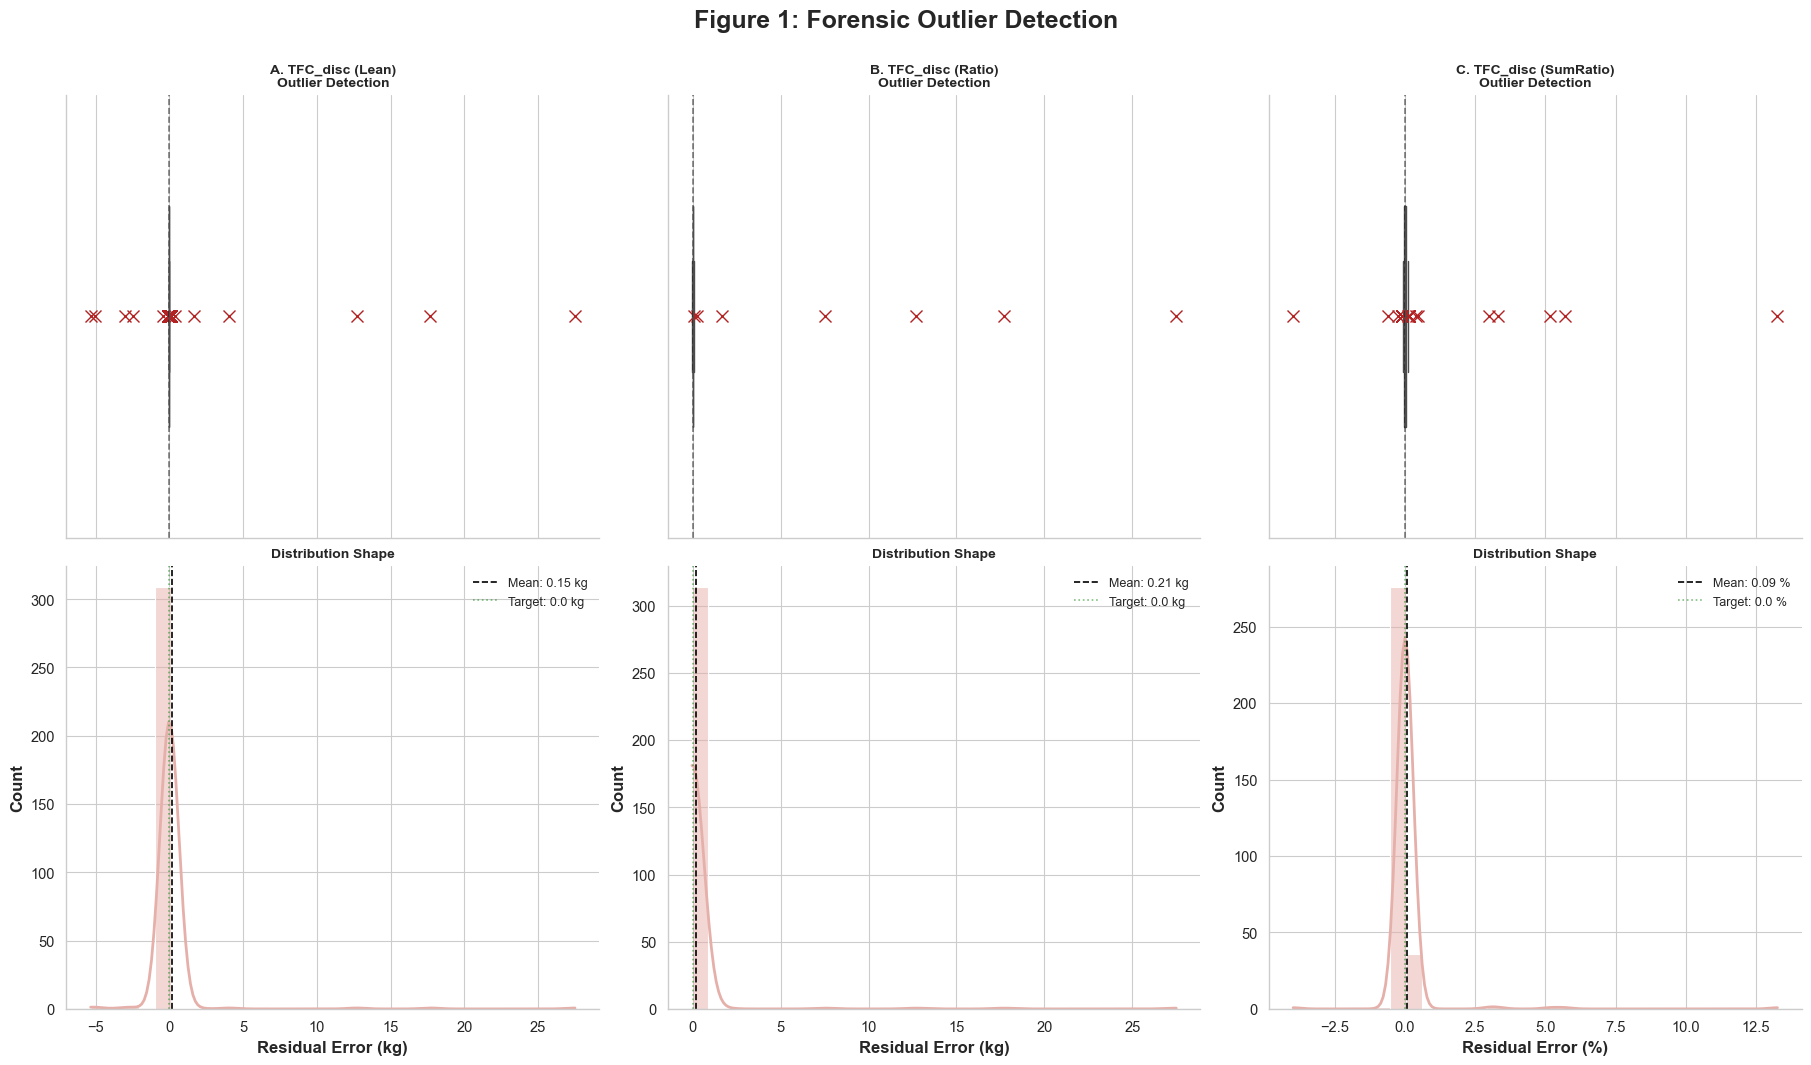

In [42]:
# --- CONFIGURATION ---
my_tracks = [
    ('A. TFC_disc (Lean)',    col_TFC_disc_lean,       'kg'),
    ('B. TFC_disc (Ratio)',   col_TFC_disc_ratio,      'kg'),
    ('C. TFC_disc (SumRatio)',col_TFC_disc_sumOfRatio, '%')
]

plot_all_tracks(df_bioimpedance, my_tracks, figure_title="Figure 1: Forensic Outlier Detection")

In [43]:
TFC_disc_lean_lim_val = get_limits(df_bioimpedance[col_TFC_disc_lean],reference_col=df_bioimpedance['Total Fat Content (TFC)'])
TFC_disc_ratio_lim_val = get_limits(df_bioimpedance[col_TFC_disc_ratio],reference_col=df_bioimpedance['Total Fat Content (TFC)'])
TFC_disc_sumOfRatio_lim_val = 1

# 2. GENERATE MASKS (Using the new symmetric limits)
TFC_disc_fit_lean_lim   = (df_bioimpedance[col_TFC_disc_lean].abs() < TFC_disc_lean_lim_val)
TFC_disc_fit_ratio_lim  = (df_bioimpedance[col_TFC_disc_ratio].abs() < TFC_disc_ratio_lim_val)
TFC_disc_sumOfRatio_lim = (df_bioimpedance[col_TFC_disc_sumOfRatio].abs() < TFC_disc_sumOfRatio_lim_val)

TFC_disc_fit_both_lim       =  TFC_disc_fit_lean_lim &  TFC_disc_fit_ratio_lim
TFC_disc_fail_lean_lim      = ~TFC_disc_fit_lean_lim &  TFC_disc_fit_ratio_lim
TFC_disc_fail_ratio_lim     =  TFC_disc_fit_lean_lim & ~TFC_disc_fit_ratio_lim
TFC_disc_fit_sumOfRatio_lim = ~TFC_disc_fit_lean_lim & ~TFC_disc_fit_ratio_lim &  TFC_disc_sumOfRatio_lim
TFC_disc_fail_all_lim       = ~TFC_disc_fit_lean_lim & ~TFC_disc_fit_ratio_lim & ~TFC_disc_sumOfRatio_lim

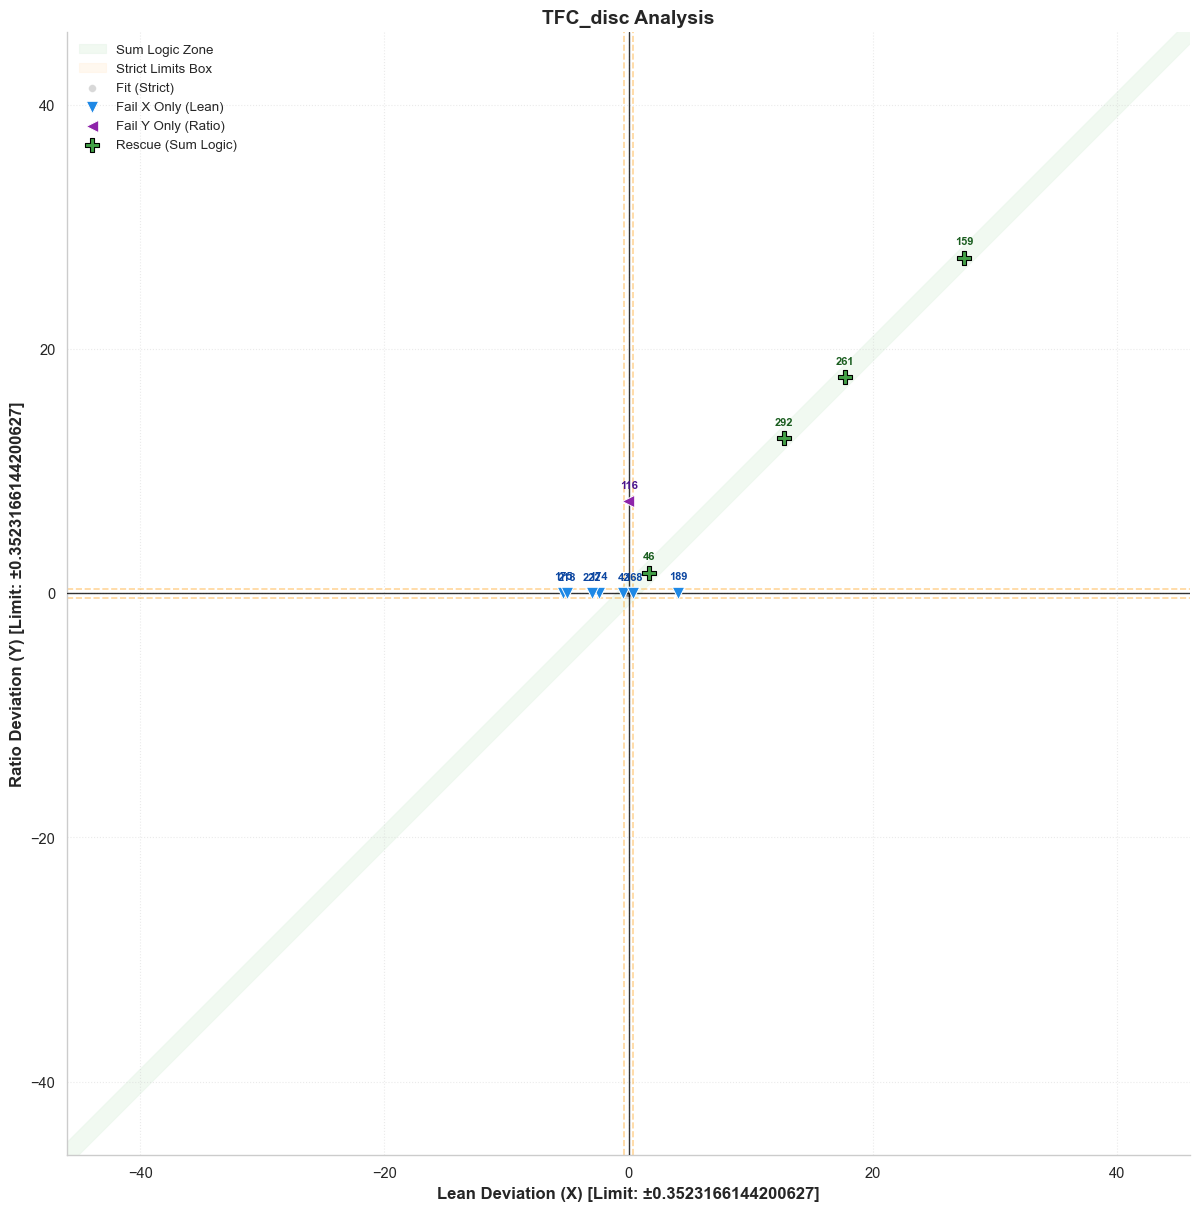

In [44]:
# --- 1. DEFINE YOUR TRACK CONFIGURATION ---
current_track = {
    'title': "TFC_disc Analysis",

    # Columns
    'x_col': col_TFC_disc_lean,           # Your X data column
    'y_col': col_TFC_disc_ratio,          # Your Y data column

    # Limits (Values)
    'lim_x': TFC_disc_lean_lim_val,       # e.g. 2.5
    'lim_y': TFC_disc_ratio_lim_val,      # e.g. 3.0
    'lim_sum': TFC_disc_sumOfRatio_lim_val, # e.g. 4.0

    # Masks (Boolean Series)
    'mask_fit': TFC_disc_fit_both_lim,
    'mask_fail_x': TFC_disc_fail_lean_lim,
    'mask_fail_y': TFC_disc_fail_ratio_lim,
    'mask_rescue': TFC_disc_fit_sumOfRatio_lim,
    'mask_fail_all': TFC_disc_fail_all_lim
}

# --- 2. EXECUTE ---
plot_logic_map(df_bioimpedance, current_track)

In [45]:
# Fixing TFC column
col_TFC_fixed = 'TFC_fixed'
df_bioimpedance[col_TFC_fixed] = df_bioimpedance['Total Fat Content (TFC)']
col_TFC_fix_status = 'TFC_fixed_status'
df_bioimpedance[col_TFC_fix_status] = False

col_TBFR_fixed = 'TBFR_fixed'
df_bioimpedance[col_TBFR_fixed] = df_bioimpedance['Total Body Fat Ratio (TBFR) (%)']
col_TBFR_fix_status = 'TBFR_fixed_status'
df_bioimpedance[col_TBFR_fix_status] = False

col_LM_fixed = 'LM_fixed'
df_bioimpedance[col_LM_fixed] = df_bioimpedance['Lean Mass (LM) (%)']
col_LM_fix_status = 'LM_fixed_status'
df_bioimpedance[col_LM_fix_status] = False


col_LM_calc_sum = 'LM_calc_sum'
df_bioimpedance[col_LM_calc_sum] = 100 - df_bioimpedance['Total Body Fat Ratio (TBFR) (%)']
df_bioimpedance.loc[TFC_disc_fail_lean_lim, col_LM_fixed] = df_bioimpedance.loc[TFC_disc_fail_lean_lim,col_LM_calc_sum]
df_bioimpedance.loc[TFC_disc_fail_lean_lim, col_LM_fix_status] = True

col_TBFR_calc_ratio = 'TBFR_calc_ratio'
df_bioimpedance[col_TBFR_calc_ratio] = df_bioimpedance['Total Fat Content (TFC)']/df_bioimpedance['Weight'] * 100
df_bioimpedance.loc[TFC_disc_fail_ratio_lim, col_TBFR_fixed] = df_bioimpedance.loc[TFC_disc_fail_ratio_lim,col_TBFR_calc_ratio]
df_bioimpedance.loc[TFC_disc_fail_ratio_lim, col_TBFR_fix_status] = True

df_bioimpedance.loc[TFC_disc_fit_sumOfRatio_lim, col_TFC_fixed] = df_bioimpedance.loc[TFC_disc_fit_sumOfRatio_lim,col_TFC_calc_ratio]
df_bioimpedance.loc[TFC_disc_fit_sumOfRatio_lim, col_TFC_fix_status] = True

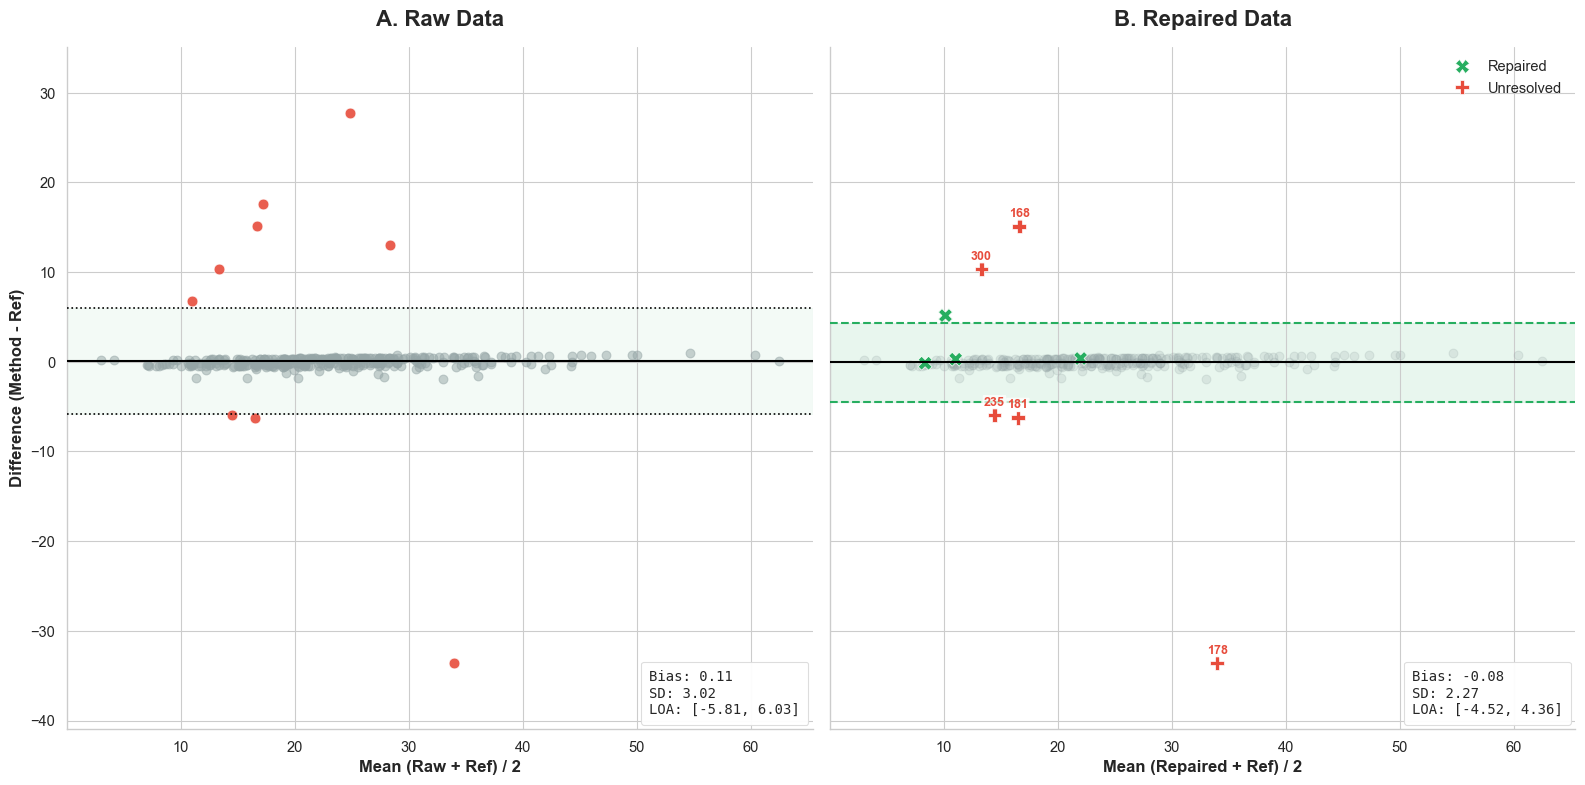

In [46]:
col_TFC_calc_4C_TBW_unfixed = 'TFC_calc_4C_TBW_unfixed'
df_bioimpedance[col_TFC_calc_4C_TBW_unfixed] = df_bioimpedance['Weight'] - df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance['Bone Mass (BM)'] - df_bioimpedance[col_TPC_calc_ratio] - epsilon_4C

col_TFC_mean_raw_TBW_unfixed = 'TFC_mean_raw_TBW_unfixed'
df_bioimpedance[col_TFC_mean_raw_TBW_unfixed] = (df_bioimpedance['Total Fat Content (TFC)'] + df_bioimpedance[col_TFC_calc_4C_TBW_unfixed]) / 2

col_TFC_diff_raw_TBW_unfixed = 'TFC_diff_raw_TBW_unfixed'
df_bioimpedance[col_TFC_diff_raw_TBW_unfixed] = df_bioimpedance['Total Fat Content (TFC)'] - df_bioimpedance[col_TFC_calc_4C_TBW_unfixed]

col_TFC_mean_fixed_TBW_unfixed = 'TFC_mean_fixed_TBW_unfixed'
df_bioimpedance[col_TFC_mean_fixed_TBW_unfixed] = (df_bioimpedance[col_TFC_fixed] + df_bioimpedance[col_TFC_calc_4C_TBW_unfixed]) / 2

col_TFC_diff_fixed_TBW_unfixed = 'TFC_diff_fixed_TBW_unfixed'
df_bioimpedance[col_TFC_diff_fixed_TBW_unfixed] = df_bioimpedance[col_TFC_fixed] - df_bioimpedance[col_TFC_calc_4C_TBW_unfixed]

_Bland_Altman_comparison(
    df_bioimpedance,
    col_TFC_mean_raw_TBW_unfixed,
    col_TFC_diff_raw_TBW_unfixed,
    col_TFC_mean_fixed_TBW_unfixed,
    col_TFC_diff_fixed_TBW_unfixed,
    col_TFC_fix_status
)

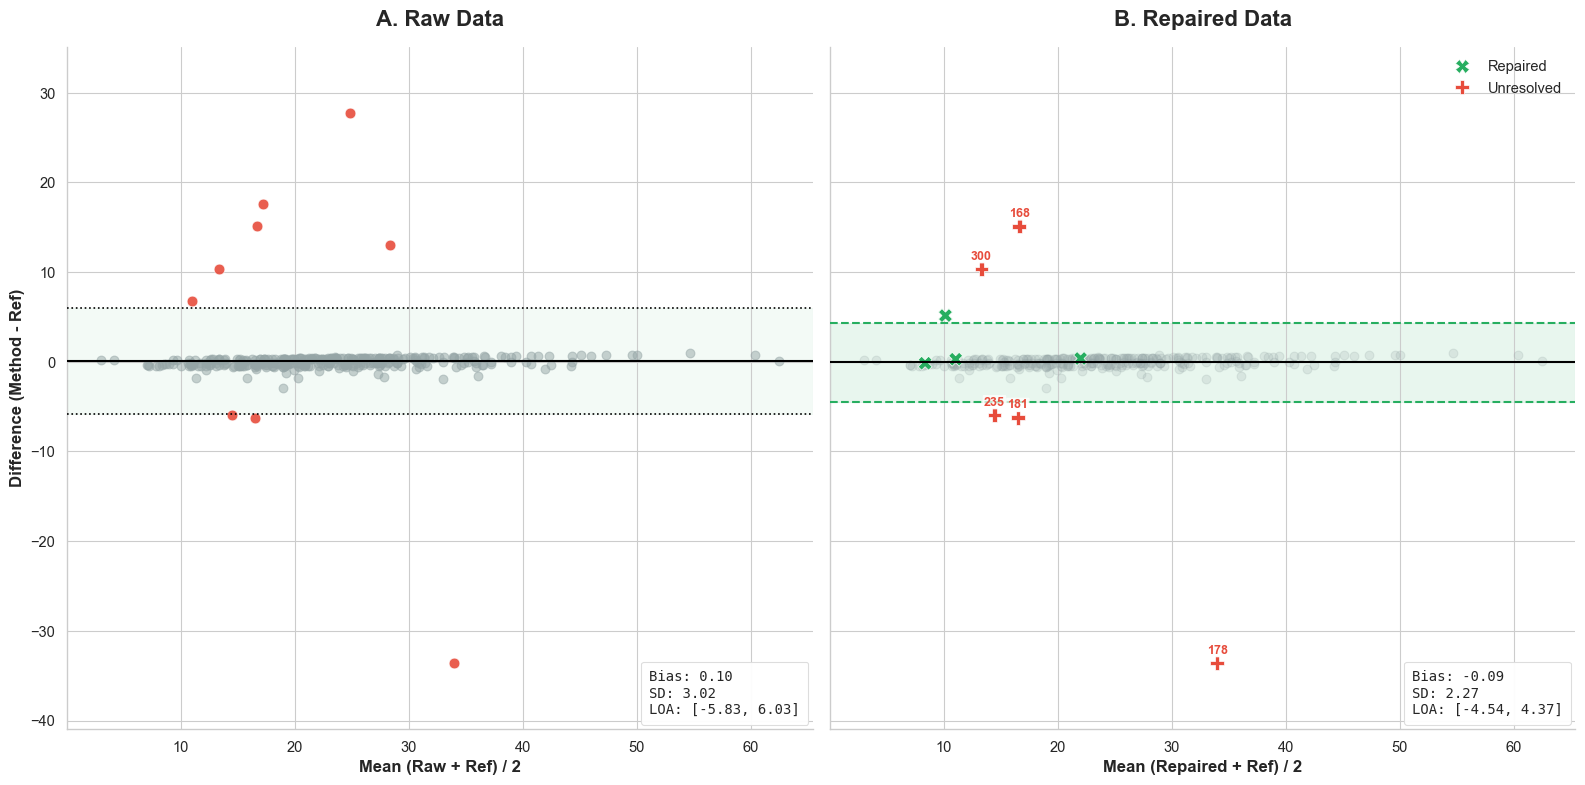

In [47]:
col_TFC_calc_4C_TBW_fixed = 'TFC_calc_4C_TBW_fixed'
df_bioimpedance[col_TFC_calc_4C_TBW_fixed] = df_bioimpedance['Weight'] - df_bioimpedance[col_TBW_fixed] - df_bioimpedance['Bone Mass (BM)'] - df_bioimpedance[col_TPC_calc_ratio] - epsilon_4C

col_TFC_mean_raw_TBW_fixed = 'TFC_mean_raw_TBW_fixed'
df_bioimpedance[col_TFC_mean_raw_TBW_fixed] = (df_bioimpedance['Total Fat Content (TFC)'] + df_bioimpedance[col_TFC_calc_4C_TBW_fixed]) / 2

col_TFC_diff_raw_TBW_fixed = 'TFC_diff_raw_TBW_fixed'
df_bioimpedance[col_TFC_diff_raw_TBW_fixed] = df_bioimpedance['Total Fat Content (TFC)'] - df_bioimpedance[col_TFC_calc_4C_TBW_fixed]

col_TFC_mean_fixed_TBW_fixed = 'TFC_mean_fixed_TBW_fixed'
df_bioimpedance[col_TFC_mean_fixed_TBW_fixed] = (df_bioimpedance[col_TFC_fixed] + df_bioimpedance[col_TFC_calc_4C_TBW_fixed]) / 2

col_TFC_diff_fixed_TBW_fixed = 'TFC_diff_fixed_TBW_fixed'
df_bioimpedance[col_TFC_diff_fixed_TBW_fixed] = df_bioimpedance[col_TFC_fixed] - df_bioimpedance[col_TFC_calc_4C_TBW_fixed]

_Bland_Altman_comparison(
    df_bioimpedance,
    col_TFC_mean_raw_TBW_fixed,
    col_TFC_diff_raw_TBW_fixed,
    col_TFC_mean_fixed_TBW_fixed,
    col_TFC_diff_fixed_TBW_fixed,
    col_TFC_fix_status
)

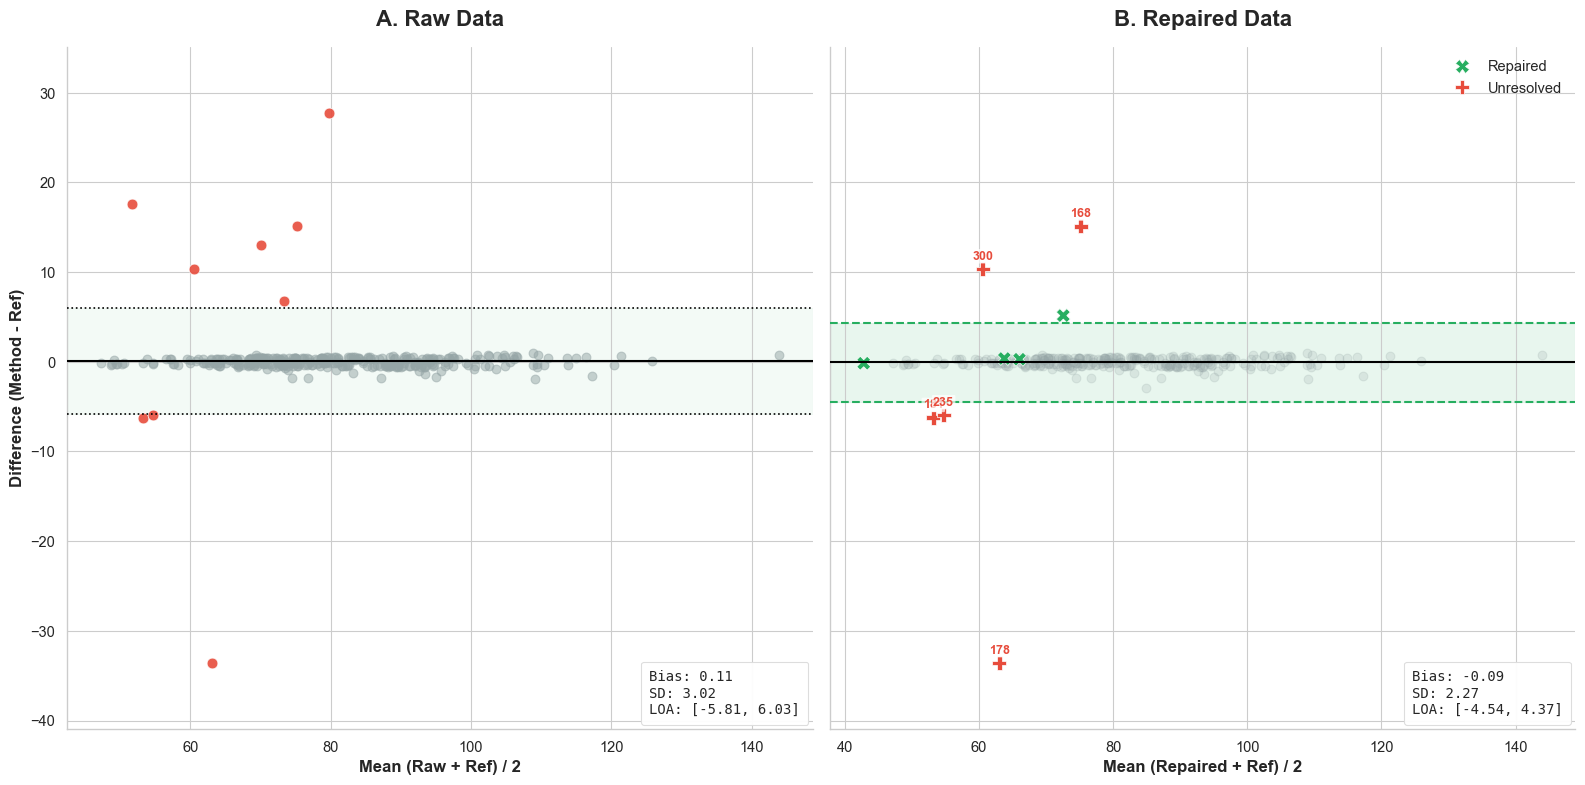

In [48]:
# ==========================================
# 1. Define the Sums (Method)
# ==========================================

# A. Original Sum (Raw TBW + Raw TFC + Constants)
col_Sum_Original = 'Sum_Components_Original'
df_bioimpedance[col_Sum_Original] = (
    df_bioimpedance['Total Body Water (TBW)'] +
    df_bioimpedance['Total Fat Content (TFC)'] +
    df_bioimpedance['Bone Mass (BM)'] +
    df_bioimpedance[col_TPC_calc_ratio] +
    epsilon_4C
)

# B. Fixed Sum (Fixed TBW + Fixed TFC + Constants)
col_Sum_Fixed = 'Sum_Components_Fixed'
df_bioimpedance[col_Sum_Fixed] = (
    df_bioimpedance[col_TBW_fixed] +
    df_bioimpedance[col_TFC_fixed] +
    df_bioimpedance['Bone Mass (BM)'] +
    df_bioimpedance[col_TPC_calc_ratio] +
    epsilon_4C
)

# ==========================================
# 2. Prepare Bland-Altman Vectors
# ==========================================

# --- Panel A: Raw Sum vs Weight ---
col_Mean_Raw_Weight = 'Mean_SumRaw_Weight'
# Mean = (Sum + Weight) / 2
df_bioimpedance[col_Mean_Raw_Weight] = (df_bioimpedance[col_Sum_Original] + df_bioimpedance['Weight']) / 2

col_Diff_Raw_Weight = 'Diff_SumRaw_Weight'
# Difference = Method (Sum) - Reference (Weight)
df_bioimpedance[col_Diff_Raw_Weight] = df_bioimpedance[col_Sum_Original] - df_bioimpedance['Weight']

# --- Panel B: Fixed Sum vs Weight ---
col_Mean_Fixed_Weight = 'Mean_SumFixed_Weight'
df_bioimpedance[col_Mean_Fixed_Weight] = (df_bioimpedance[col_Sum_Fixed] + df_bioimpedance['Weight']) / 2

col_Diff_Fixed_Weight = 'Diff_SumFixed_Weight'
df_bioimpedance[col_Diff_Fixed_Weight] = df_bioimpedance[col_Sum_Fixed] - df_bioimpedance['Weight']

# ==========================================
# 3. Execute Comparison
# ==========================================
_Bland_Altman_comparison(
    df_bioimpedance,
    col_Mean_Raw_Weight,    # Panel A X-axis
    col_Diff_Raw_Weight,    # Panel A Y-axis
    col_Mean_Fixed_Weight,  # Panel B X-axis
    col_Diff_Fixed_Weight,  # Panel B Y-axis
    col_TFC_fix_status      # Coloring Logic
)